# ChurnGuard — Exploratory Data Analysis

Dataset: IBM Telco Customer Churn (7,043 customers, 21 columns).

Goal: understand *who* churns and *why*, before any modeling — this notebook
is the "story" artifact; `train.py` is the production training script that
reuses the same cleaning/feature logic via `app.data_prep` and `app.features`.


In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from app.data_prep import load_clean
from app.features import engineer

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

df = load_clean("../data/telco_churn.csv")
df = engineer(df)
df.shape


(7043, 24)

## 1. Class balance — how imbalanced is churn, really?

Overall churn rate: 26.5%


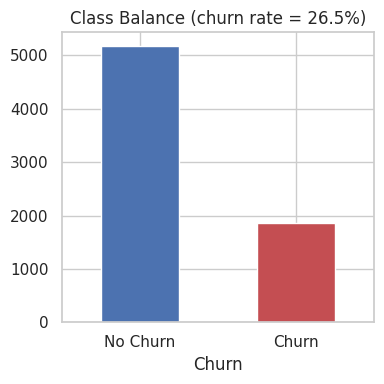

In [2]:
churn_rate = df["Churn"].mean()
print(f"Overall churn rate: {churn_rate:.1%}")

ax = df["Churn"].value_counts().plot(kind="bar", figsize=(4,4), color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["No Churn", "Churn"], rotation=0)
ax.set_title(f"Class Balance (churn rate = {churn_rate:.1%})")
plt.tight_layout()
plt.show()


**Finding:** ~26.5% of customers churned. This isn't a rare-event problem
(like fraud at <1%), but it's imbalanced enough that plain accuracy would be
misleading — a model that always predicts "no churn" would already score 73.5%
accuracy while catching zero at-risk customers. This is why we evaluate on
precision/recall/ROC-AUC instead, and use class weighting during training.

## 2. Contract type — the single strongest signal

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64


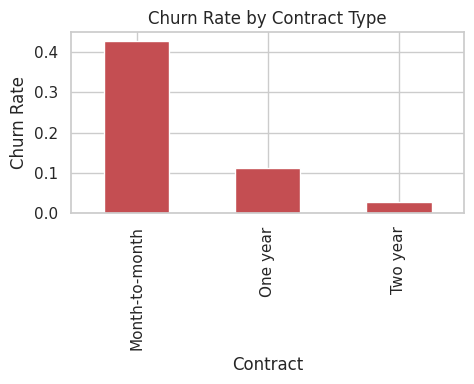

In [3]:
contract_churn = df.groupby("Contract")["Churn"].mean().sort_values(ascending=False)
print(contract_churn)

ax = contract_churn.plot(kind="bar", figsize=(5,4), color="#C44E52")
ax.set_ylabel("Churn Rate")
ax.set_title("Churn Rate by Contract Type")
plt.tight_layout()
plt.show()


**Finding:** Month-to-month customers churn at roughly 3-4x the rate of
one/two-year contract customers. This single feature ends up as the top SHAP
driver in the trained model later — no surprise, since contract length is
directly tied to switching cost/friction.

## 3. Tenure — risk is front-loaded

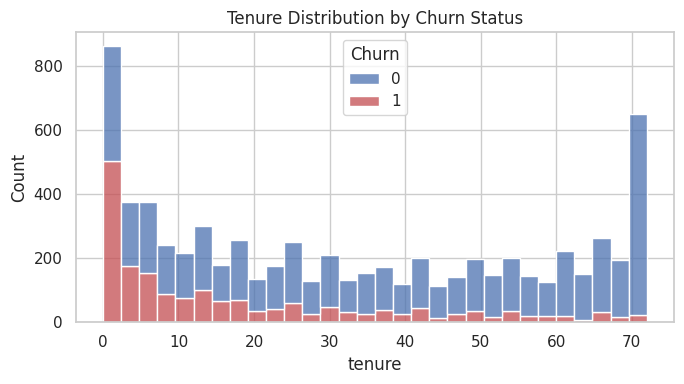

In [4]:
fig, ax = plt.subplots(figsize=(7,4))
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", bins=30, palette=["#4C72B0","#C44E52"])
ax.set_title("Tenure Distribution by Churn Status")
plt.tight_layout()
plt.show()


**Finding:** Churn is heavily concentrated in the first ~12 months. This
is the classic "early relationship risk" pattern seen in subscription
businesses — customers who make it past year one are meaningfully stickier.
This motivated the `tenure_bucket` engineered feature.

## 4. Internet service type & add-on services

InternetService
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Churn, dtype: float64


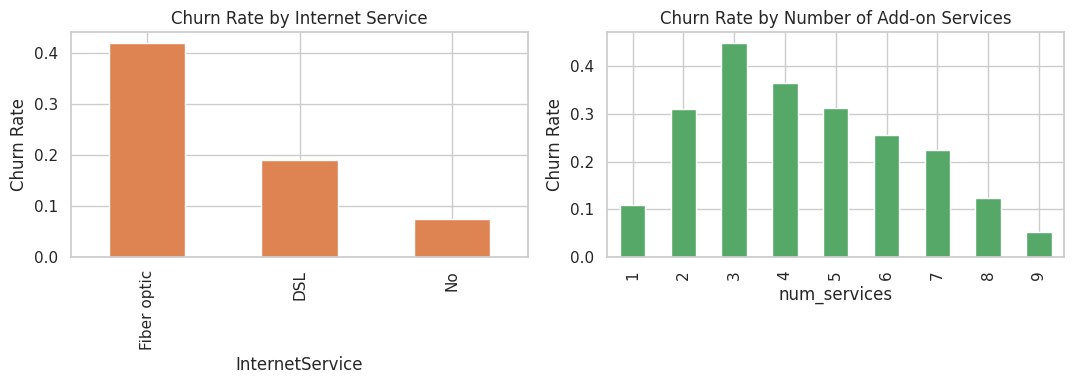

In [5]:
internet_churn = df.groupby("InternetService")["Churn"].mean().sort_values(ascending=False)
print(internet_churn)

fig, axes = plt.subplots(1, 2, figsize=(11,4))
internet_churn.plot(kind="bar", ax=axes[0], color="#DD8452")
axes[0].set_title("Churn Rate by Internet Service")
axes[0].set_ylabel("Churn Rate")

services_churn = df.groupby("num_services")["Churn"].mean()
services_churn.plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Churn Rate by Number of Add-on Services")
axes[1].set_ylabel("Churn Rate")
plt.tight_layout()
plt.show()


**Finding:** Fiber optic customers churn more than DSL customers despite
(or because of) paying more — likely a price-sensitivity or service-quality
signal worth flagging to the business. Customers with more add-on services
(online security, tech support, etc.) churn less — consistent with the
"switching friction" hypothesis: more integrated services, more inconvenient
to leave.

## 5. Monthly charges vs churn

/tmp/ipykernel_543/4106210514.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette=["#4C72B0","#C44E52"])
/tmp/ipykernel_543/4106210514.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Churn", "Churn"])


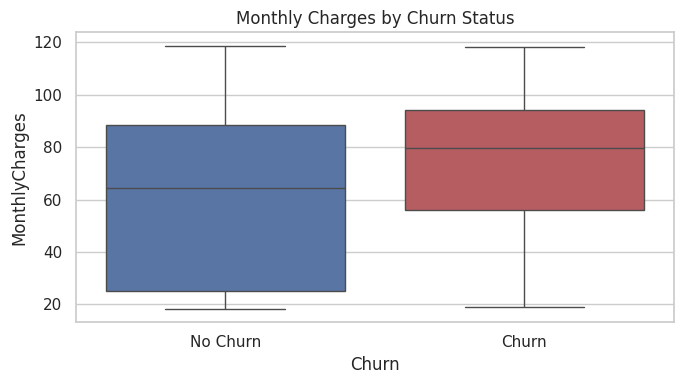

In [6]:
fig, ax = plt.subplots(figsize=(7,4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette=["#4C72B0","#C44E52"])
ax.set_xticklabels(["No Churn", "Churn"])
ax.set_title("Monthly Charges by Churn Status")
plt.tight_layout()
plt.show()


**Finding:** Churned customers have a noticeably higher median monthly
bill. Combined with the fiber-optic finding above, this points to a
price-sensitivity story worth surfacing to a retention/pricing team.

## 6. Summary of EDA findings that fed into feature engineering

| Finding | Engineered Feature |
|---|---|
| Month-to-month dominates churn | `contract_risk` (ordinal risk encoding) |
| Risk is front-loaded in first 12 months | `tenure_bucket` |
| More add-on services = stickier | `num_services` |
| Fiber/high-bill customers churn more | kept `MonthlyCharges`, added `avg_monthly_spend_ratio` |

Next step: `train.py` — model comparison, class-imbalance handling, and
SHAP-based explainability on the full feature set.